<a href="https://colab.research.google.com/github/JoshuaCora1806/mi-lab05-cs/blob/develop/LAB05_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

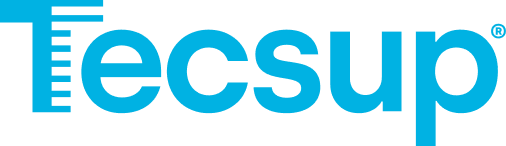

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
# Carrera de Big Data y Ciencia de Datos
# LABORATORIO 5
Joshua Jian Cora Salazar

Indicaciones:
- El trabajo en su totalidad debe ser hecho en un notebook de ‘Jupyter’.
- Cree una cabecera que lleve por título el tema de la semana y debajo de él coloque un ‘Markdown’ con su nombre y apellido.
- Ejecute su notebook, grábelo, descárguelo como HTML, conviértalo a PDF y suba ambos archivos en el apartado que el docente indique.

## Pregunta A
Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.

In [2]:
# Importamos la libreria pandas para trabajar con dataframes
import pandas as pd

# Cargamos el archivo csv desde el repositorio
# Definimos la URL donde se encuentra el repositorio
url = 'https://archive.ics.uci.edu/static/public/15/data.csv'

# Usamos read_csv de pandas para leer la base de datos
df = pd.read_csv(url)

# Usamos head para ver los 5 primeros registros
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


Según el repositorio "Sample_code_number" es categórico, por otro lado, "Class" es la variable objetivo y solo tiene 2 valores que signifincan benigno y no benigno, por lo cual también son categóricas.

In [3]:
# Excluimos las variables no mnumericas, elegimos las variables numericas y las guardamos en una variable
df_num = df.drop(columns=["Sample_code_number","Class"])

# Elegimos las variables no numericas y las guardamos en una variable
df_no_num = df[["Sample_code_number","Class"]]

# Verificamos que la separacióin es correcta imprimiendo los tipos de datos de cada nuevo df
print(f" Variables numéricas:\n\n{df_num.dtypes}\n\n Variables no numéricas:\n\n{df_no_num.dtypes}")

 Variables numéricas:

Clump_thickness                  int64
Uniformity_of_cell_size          int64
Uniformity_of_cell_shape         int64
Marginal_adhesion                int64
Single_epithelial_cell_size      int64
Bare_nuclei                    float64
Bland_chromatin                  int64
Normal_nucleoli                  int64
Mitoses                          int64
dtype: object

 Variables no numéricas:

Sample_code_number    int64
Class                 int64
dtype: object


In [4]:
# Calculamos y mostramos los estadísticos descriptivos de las variables numéricas
df_num.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


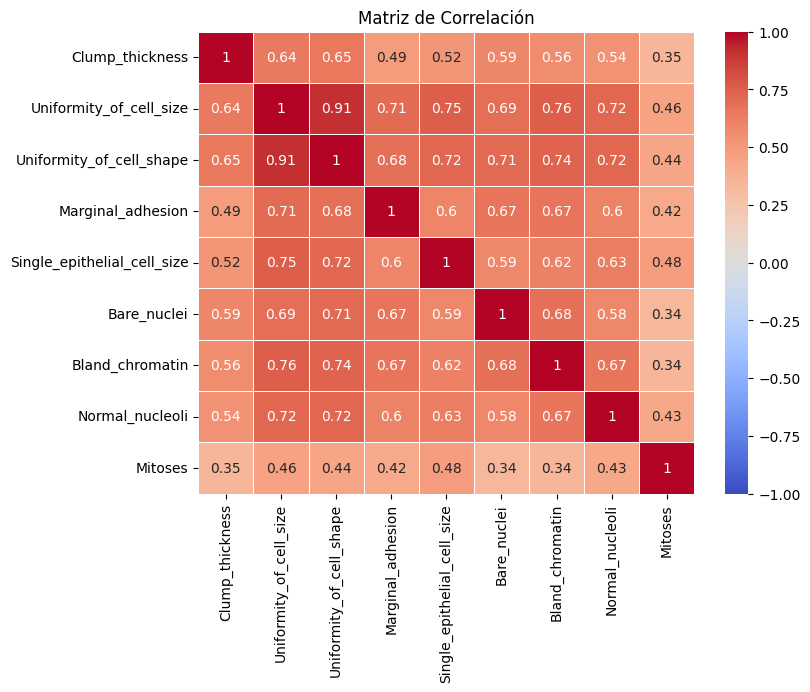

In [5]:
# Calculamos la matriz de correlación de las variables numpericas a través del comando cor()
corr_matrix=df_num.corr()

# Importamos seaborn para la creaación del grafico de calor
import seaborn as sns

# Importamos matplotlib para la visualización
import matplotlib.pyplot as plt

# Creamos el gráfico de calor de la matriz de correlación
plt.figure(figsize=(8, 6))  # Tamaño del gráfico
sns.heatmap(
    corr_matrix,            # Matriz de correlación
    annot=True,             # Muestra los valores en cada celda
    cmap='coolwarm',        # Mapa de colores (puedes usar 'viridis', 'RdYlBu', etc.)
    vmin=-1, vmax=1,        # Rango de valores (correlación va de -1 a 1)
    linewidths=0.5          # Ancho de las líneas entre celdas
)
plt.title("Matriz de Correlación")  # Título
plt.show()

## Pregunta B
Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.

In [6]:
# Importamos las librerías necesarias para nuestro análisis
import numpy as np

In [7]:
# Establecemos el estilo visual de nuestros gráficos
plt.style.use('ggplot')

In [10]:
def graficar_histogramas(df):
    # Iteramos sobre cada columna del DataFrame
    for col in df.columns:
        # Creamos una nueva figura para el histograma
        plt.figure()
        # Calculamos y dibujamos el histograma descartando valores nulos y usando 10 bins
        plt.hist(df[col].dropna(), bins=10)
        # Definimos el título del gráfico con el nombre de la columna
        plt.title(f'Histograma de {col}')
        # Etiquetamos el eje X con el nombre de la variable
        plt.xlabel(col)
        # Etiquetamos el eje Y como 'Frecuencia'
        plt.ylabel('Frecuencia')
        # Mostramos la figura resultante
        plt.show()

def graficar_densidad(df):
    # Iteramos sobre cada columna del DataFrame
    for col in df.columns:
        # Creamos una nueva figura para el gráfico de densidad
        plt.figure()
        # Trazamos la estimación de densidad descartando valores nulos
        df[col].dropna().plot(kind='kde')
        # Definimos el título del gráfico con el nombre de la columna
        plt.title(f'Gráfico de densidad de {col}')
        # Etiquetamos el eje X con el nombre de la variable
        plt.xlabel(col)
        # Etiquetamos el eje Y como 'Densidad'
        plt.ylabel('Densidad')
        # Mostramos la figura resultante
        plt.show()

def graficar_cajas(df):
    # Iteramos sobre cada columna del DataFrame
    for col in df.columns:
        # Creamos una nueva figura para el diagrama de caja
        plt.figure()
        # Dibujamos el boxplot descartando valores nulos y orientado verticalmente
        plt.boxplot(df[col].dropna(), vert=True)
        # Definimos el título del gráfico con el nombre de la columna
        plt.title(f'Diagrama de caja de {col}')
        # Etiquetamos el eje Y con el nombre de la variable
        plt.ylabel(col)
        # Mostramos la figura resultante
        plt.show()

def graficar_dispersion(df):
    # Iteramos sobre cada columna del DataFrame
    for col in df.columns:
        # Calculamos la mediana de la columna actual, ignorando nulos
        mediana = df[col].median()
        # Reemplazamos los valores nulos por la mediana
        serie = df[col].fillna(mediana)

        # Creamos una nueva figura para el scatter plot de la variable actual
        plt.figure()
        # Trazamos los puntos usando el índice en X y los valores imputados en Y
        plt.scatter(df.index, serie)
        # Definimos el título del gráfico con la variable correspondiente
        plt.title(f'Gráfico de dispersión de {col} vs Índice')
        # Etiquetamos el eje X como 'Índice'
        plt.xlabel('Índice')
        # Etiquetamos el eje Y con el nombre de la variable
        plt.ylabel(col)
        # Mostramos la figura resultante
        plt.show()

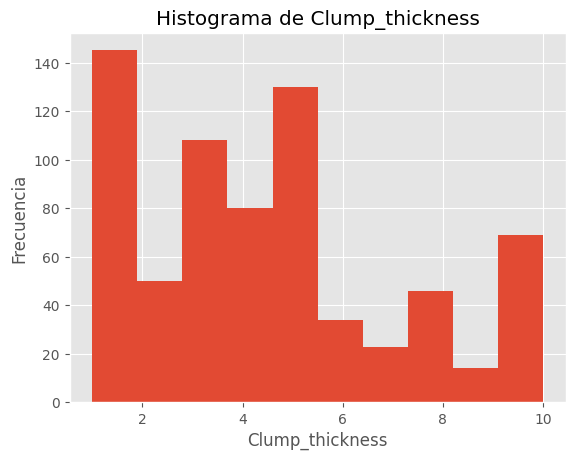

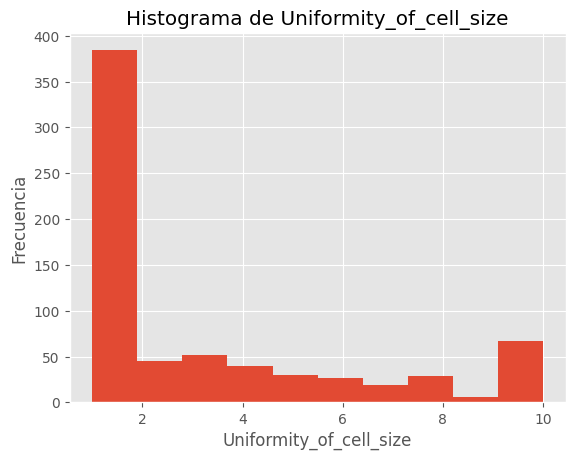

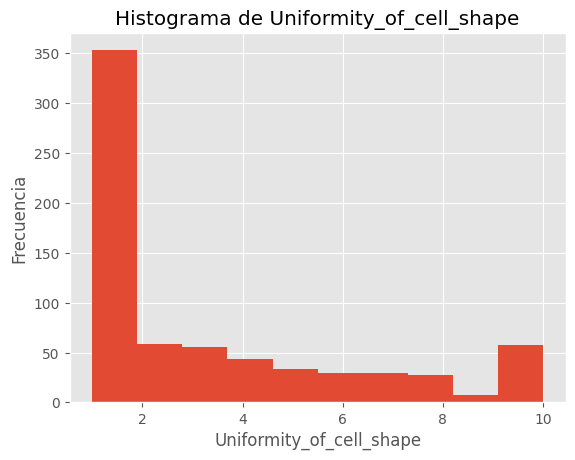

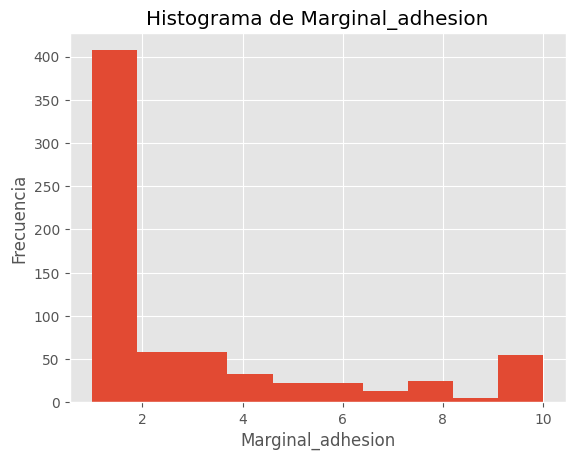

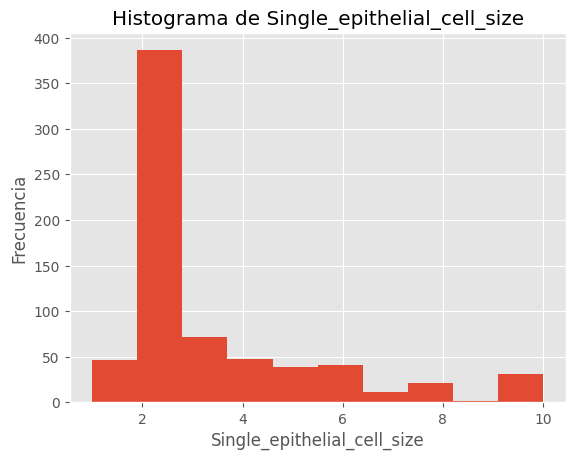

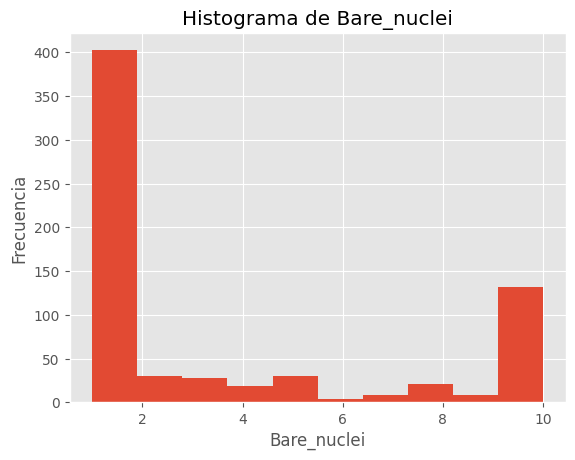

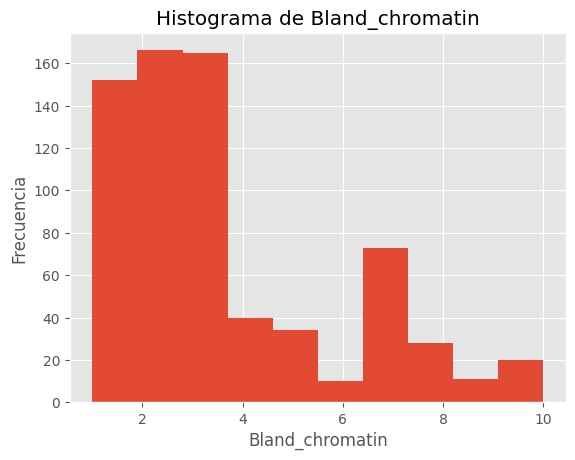

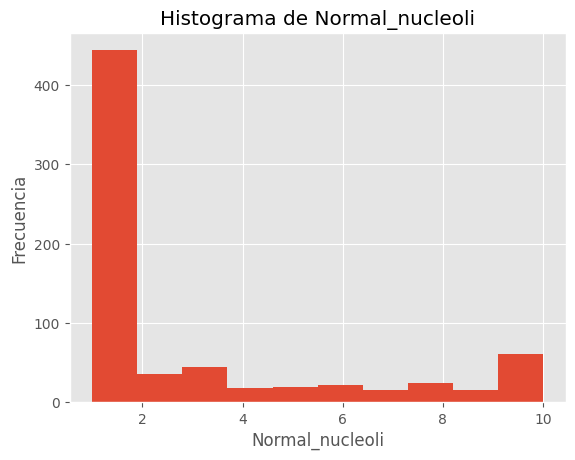

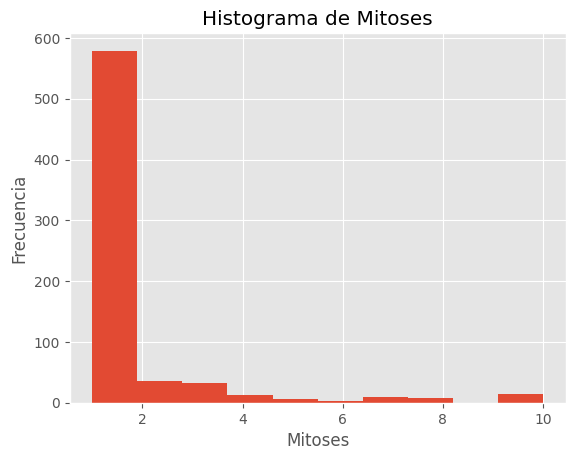

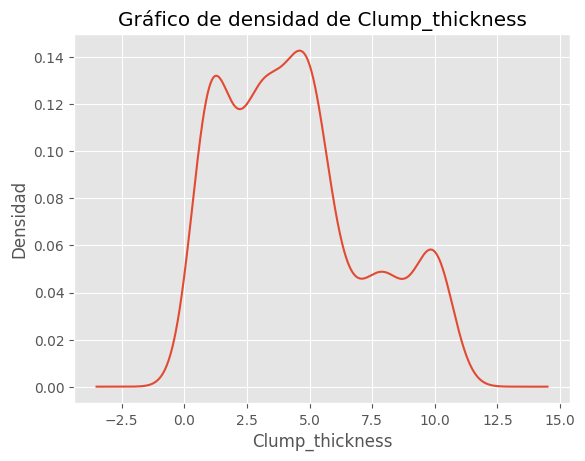

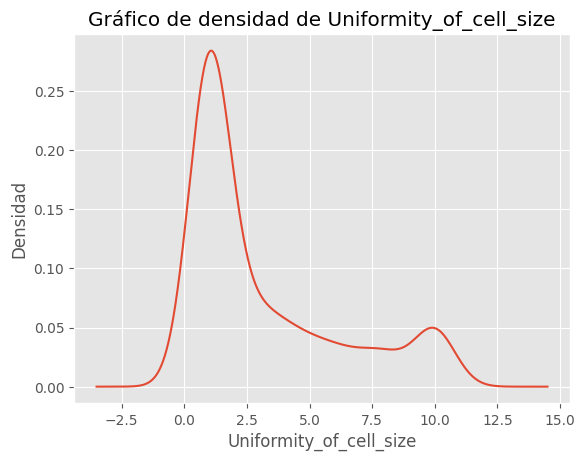

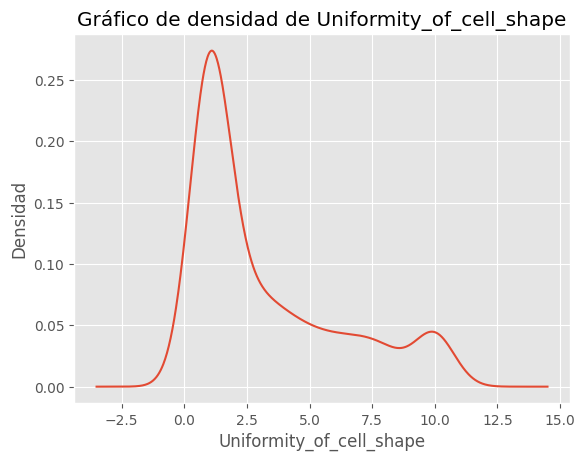

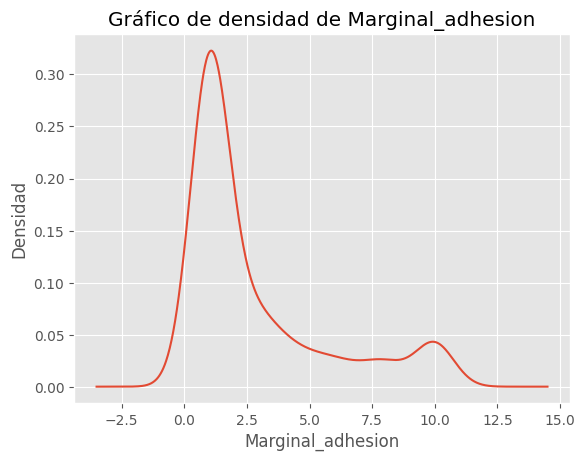

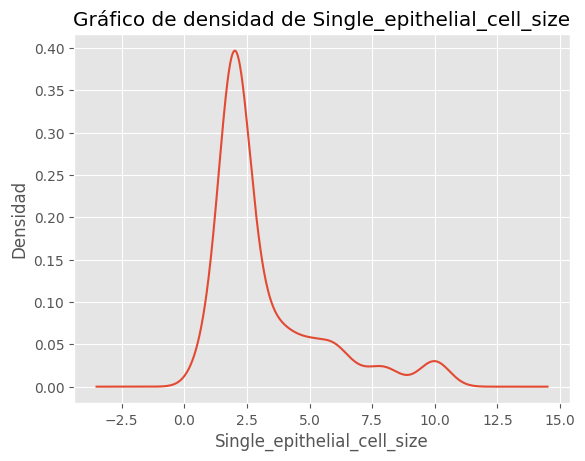

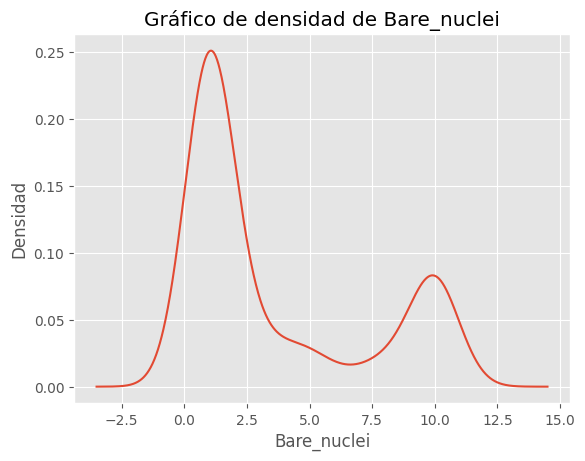

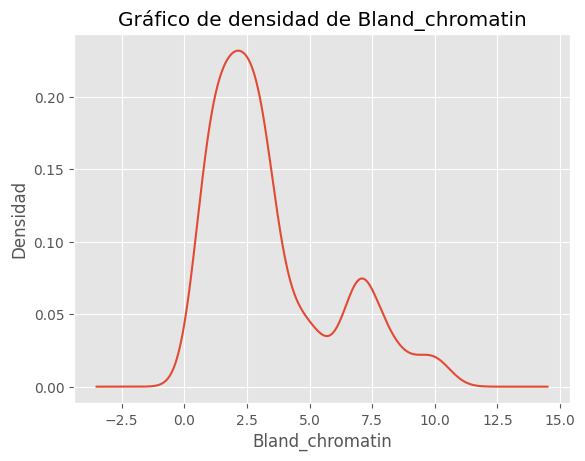

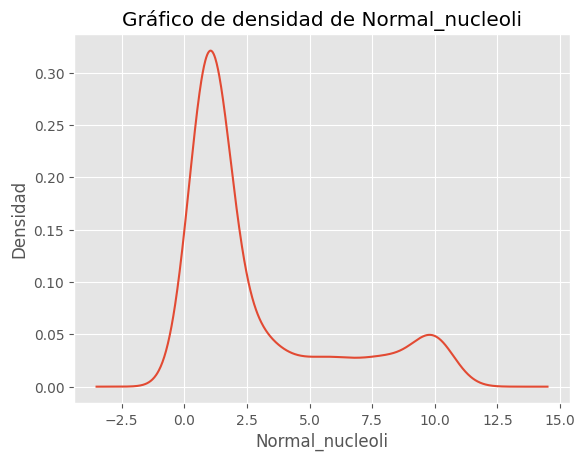

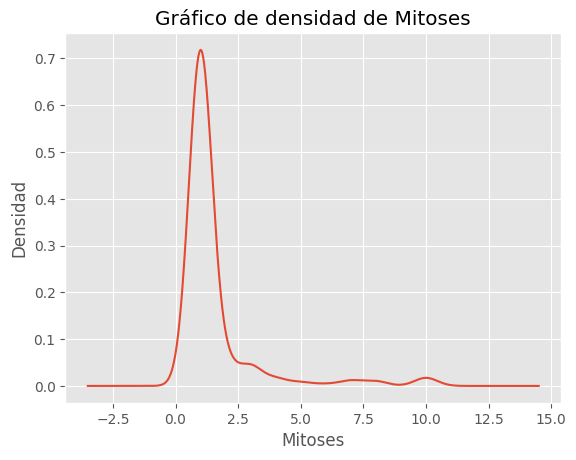

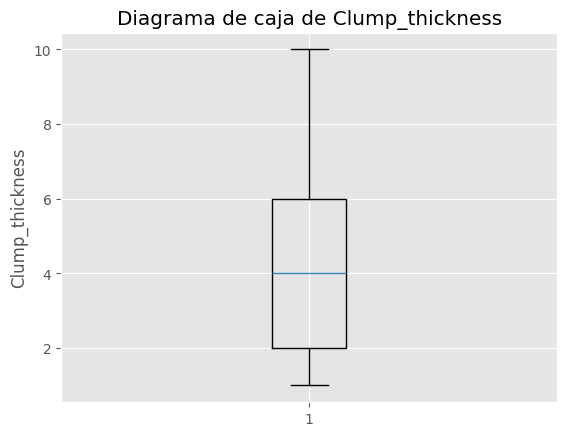

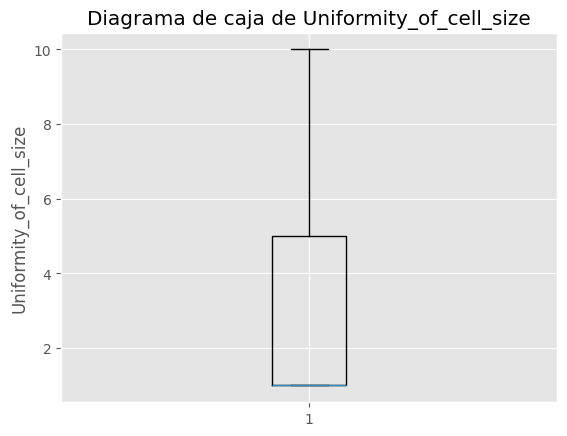

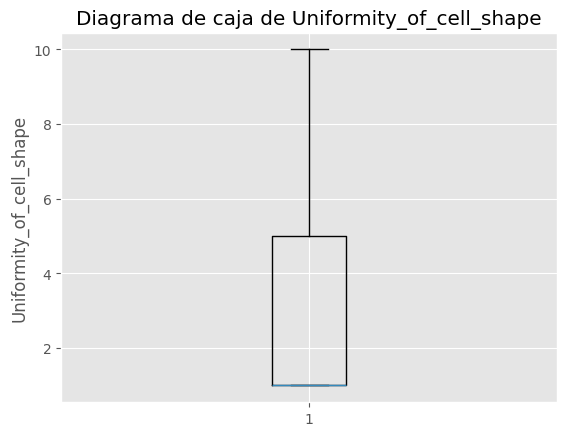

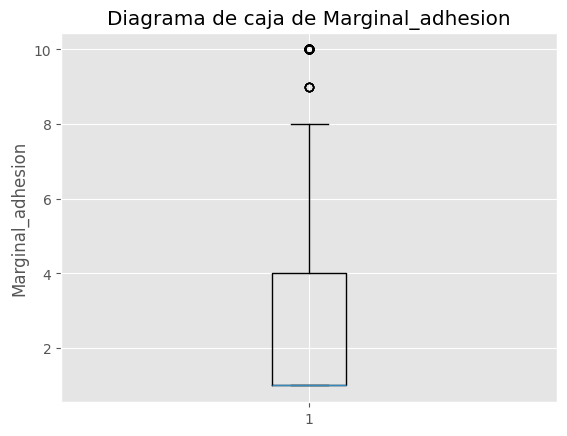

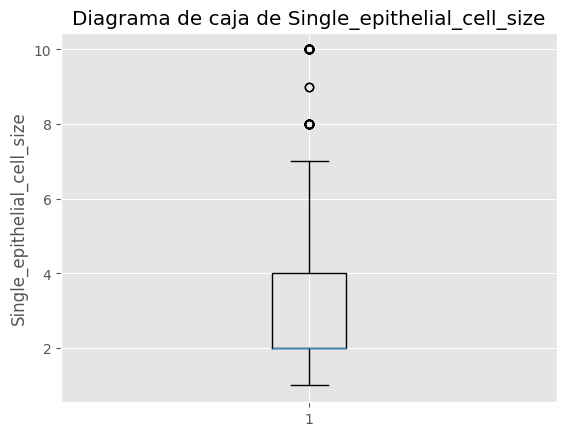

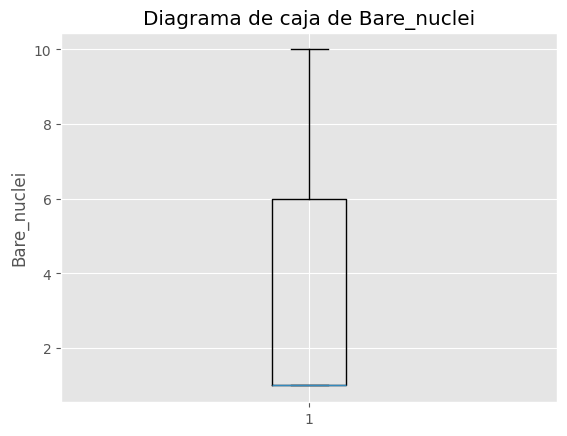

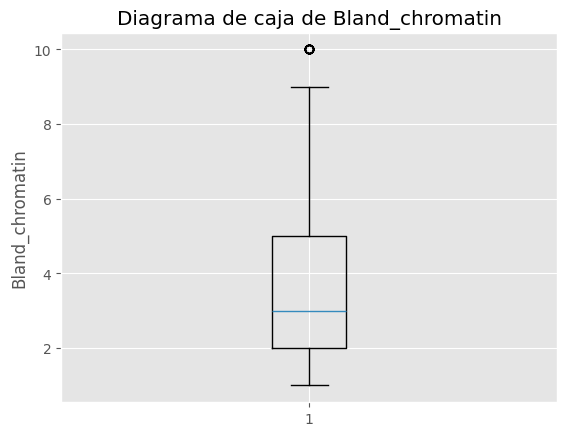

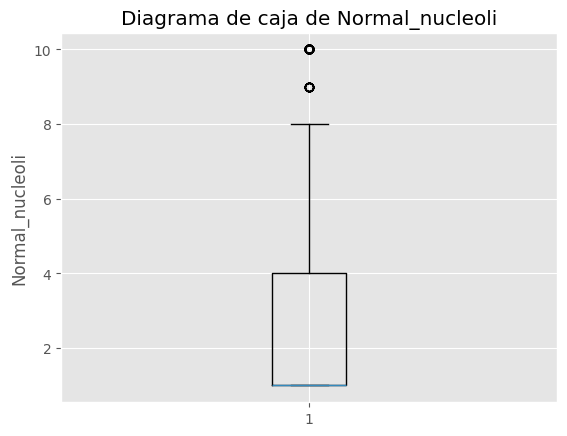

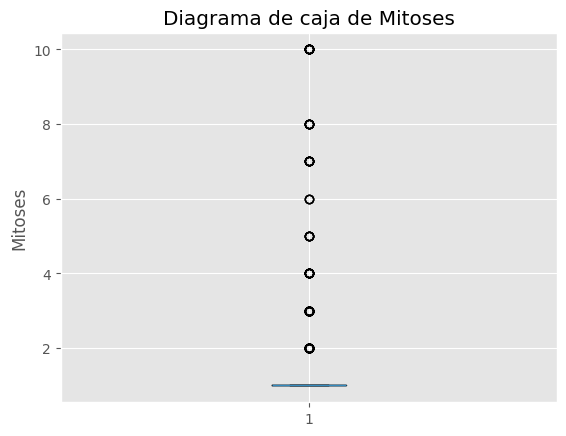

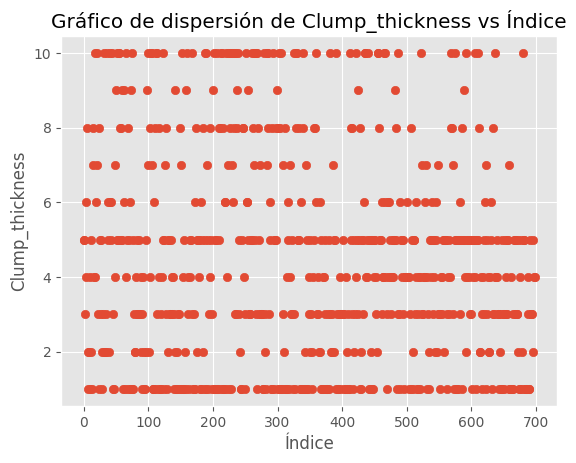

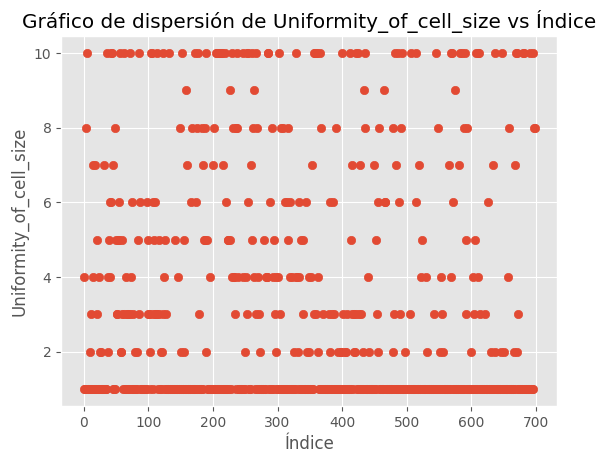

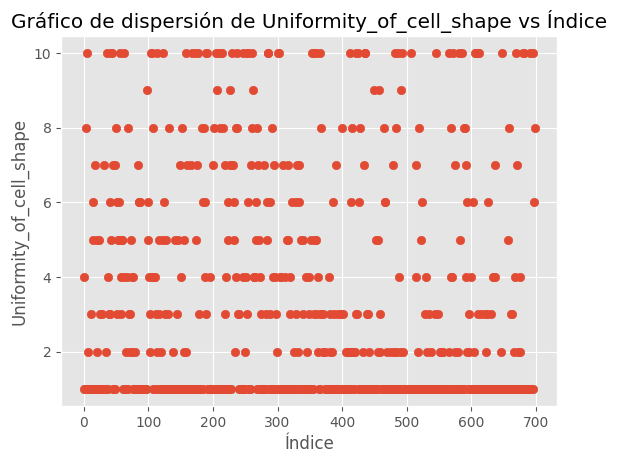

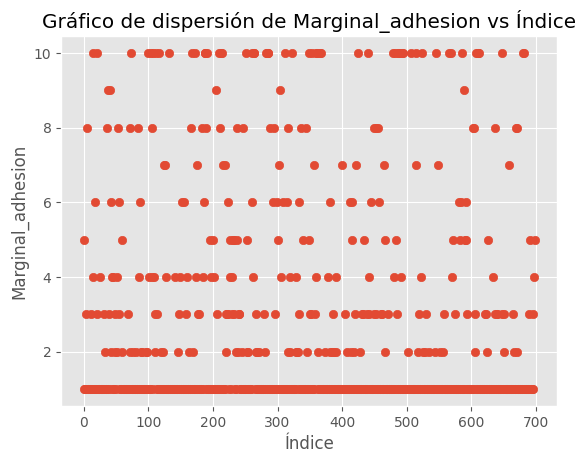

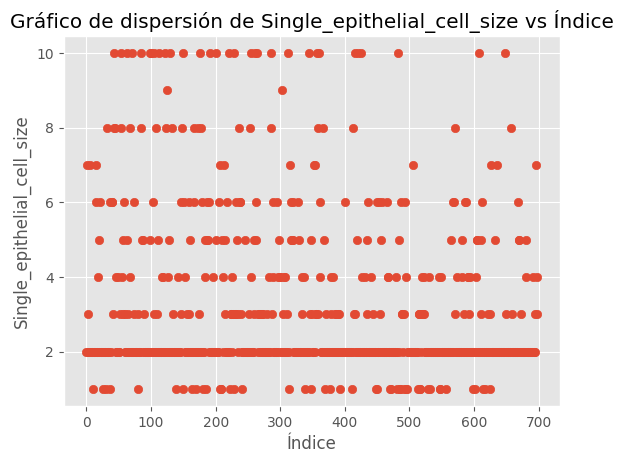

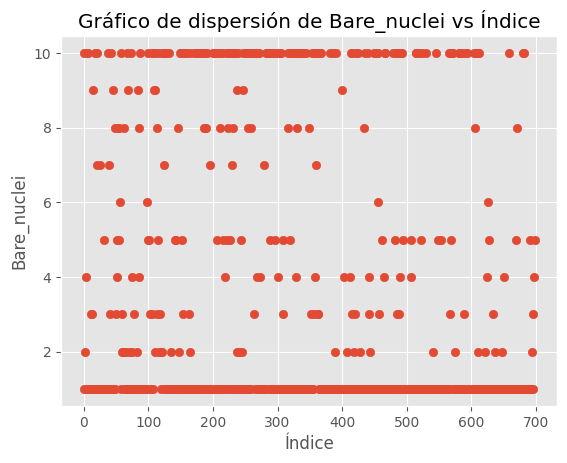

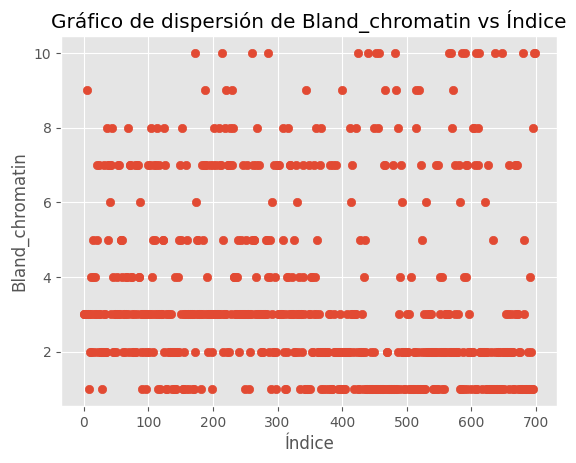

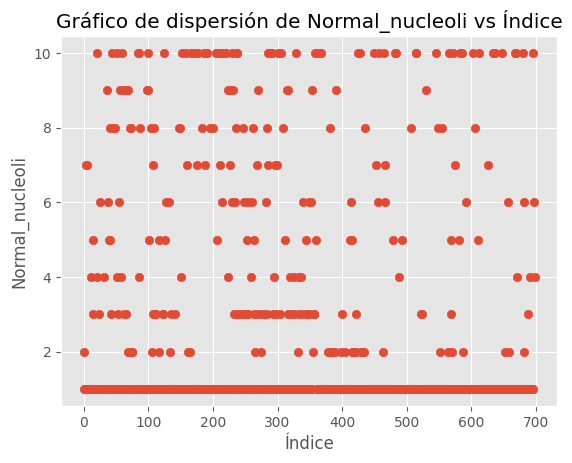

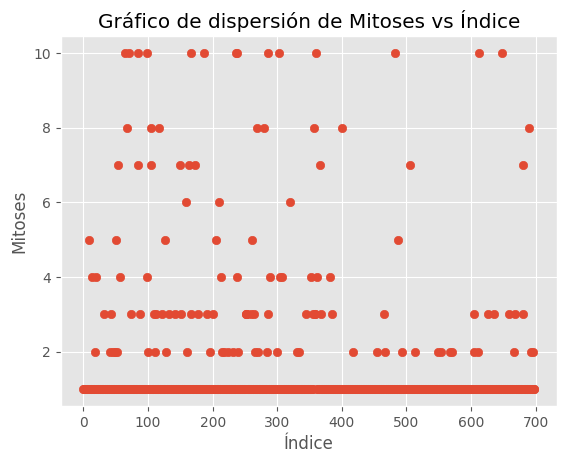

In [11]:
# Generamos todos los histogramas
graficar_histogramas(df_num)

# Generamos todos los gráficos de densidad
graficar_densidad(df_num)

# Generamos todos los diagramas de caja
graficar_cajas(df_num)

# Generamos todos los gráficos de dispersión
graficar_dispersion(df_num)

## Pregunta C
Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba. Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.

In [12]:
from sklearn.impute import SimpleImputer       # Importamos SimpleImputer para imputar valores faltantes
from sklearn.model_selection import train_test_split  # Importamos para dividir datos en entrenamiento y prueba
from sklearn.neighbors import KNeighborsClassifier    # Importamos el clasificador k-NN
from sklearn.metrics import accuracy_score     # Importamos para medir la precisión del modelo

# Imputamos los valores nulos por la mediana de cada columna
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Definimos matriz de características X y vector objetivo y
X = df_imputed.drop('Class', axis=1)  # Seleccionamos todas las columnas predictoras
y = df_imputed['Class']               # Seleccionamos la columna objetivo

# Separamos los datos en conjunto de entrenamiento y de prueba
# Usamos 30% de los datos para prueba y fijamos semilla para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Creamos e entrenamos el modelo k-NN (con k=5 vecinos)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Generamos pronósticos para entrenamiento y prueba
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Medimos la precisión en ambos conjuntos
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Mostramos los resultados
print(f'Precisión en entrenamiento: {train_acc:.3f}')
print(f'Precisión en prueba:       {test_acc:.3f}')

Precisión en entrenamiento: 0.722
Precisión en prueba:       0.614
